IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as model_selection
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files
uploaded = files.upload()
df=pd.read_csv('T2-Superstore.csv', encoding='latin1')

Saving T2-Superstore.csv to T2-Superstore.csv


DATA UNDERSTANDING & PREPARATION

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.shape

(9994, 21)

In [7]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [8]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df.nunique()

,0
Row ID,9994
Order ID,5009
Order Date,1237
Ship Date,1334
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,531


In [11]:
df['Sales'].unique()

array([261.96 , 731.94 ,  14.62 , ..., 437.472,  97.98 , 243.16 ])

In [12]:
df['Sales'].value_counts()

,count
Sales,
12.9600,56
19.4400,39
15.5520,39
10.3680,36
25.9200,36
...,...
119.5600,1
109.6900,1
13.4000,1


DATA CLEANING

In [13]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9989,False
9990,False
9991,False
9992,False


In [14]:
df.isnull()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9990,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9991,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9992,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


FEATURE ENGINEERING & SELECTION

In [16]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [17]:
#Extract year from order date
df['Year']=df['Order Date'].dt.year

In [18]:
#Extract month from order date
df['Month']=df['Order Date'].dt.month

In [19]:
#Extract day from order date
df['Day']=df['Order Date'].dt.day

In [20]:
#Extract quarter from order date
df['Quarter']=df['Order Date'].dt.quarter

In [21]:
#Extract day name from order date
df['DayOfWeek']=df['Order Date'].dt.day_name()

ENCODING

In [22]:
#Display Categorical Columns
ctg_cols=df.select_dtypes(include=["object"]).columns
print(ctg_cols)

Index(['Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name',
       'Segment', 'Country', 'City', 'State', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'DayOfWeek'],
      dtype='object')


In [23]:
label_encoder = LabelEncoder()
binary_columns=[ 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name']

In [24]:
for columns in binary_columns:
  df[columns]=label_encoder.fit_transform(df[columns])

In [25]:
df.drop(['Row ID', 'Order ID', 'order date','DayOfWeek'],axis=1,inplace=True, errors='ignore')

In [26]:
df.shape

(9994, 23)

In [27]:
df.to_csv('T2-Superstore.csv',index=False)

In [28]:
df.head()

,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,Quarter
0,864,219,2,143,166,0,0,194,15,42420,...,4,386,261.9600,2,0.00,41.9136,2016,11,8,4
1,864,219,2,143,166,0,0,194,15,42420,...,5,839,731.9400,3,0.00,219.5820,2016,11,8,4
2,732,906,2,237,201,1,0,266,3,90036,...,10,1433,14.6200,2,0.00,6.8714,2016,6,12,2
3,519,128,3,705,687,0,0,153,8,33311,...,16,366,957.5775,5,0.45,-383.0310,2015,10,11,4
4,519,128,3,705,687,0,0,153,8,33311,...,14,573,22.3680,2,0.20,2.5164,2015,10,11,4


VISUALISATION

TOP 10 STATES BY PROFIT

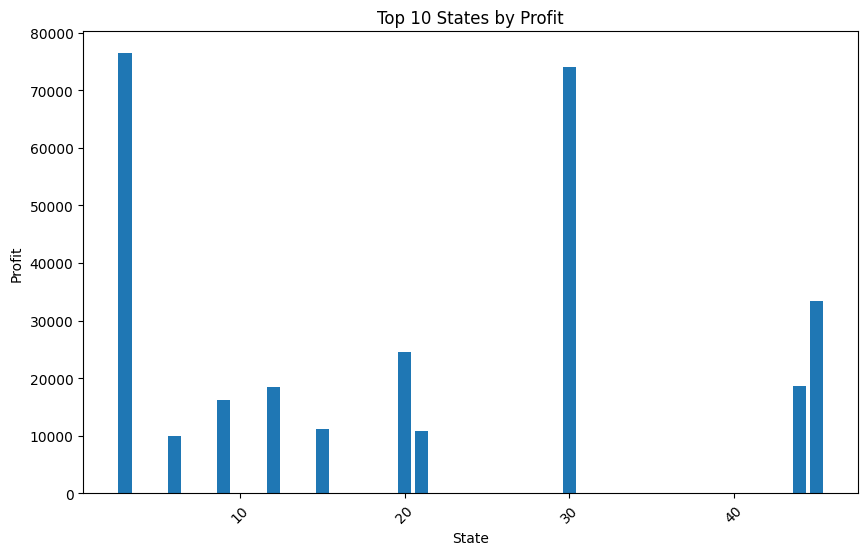

In [29]:
top_states = df.groupby("State")["Profit"].sum().nlargest(10)

plt.figure(figsize=(10,6))
plt.bar(top_states.index, top_states.values)
plt.xticks(rotation=45)
plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit")
plt.show()

OBSERVATION

  * Shows the top 10 states with the highest profit.
  * A few states contribute most of the total profit.
  * These states are the company's best-performing regions.


CATEGORY WISE SALES

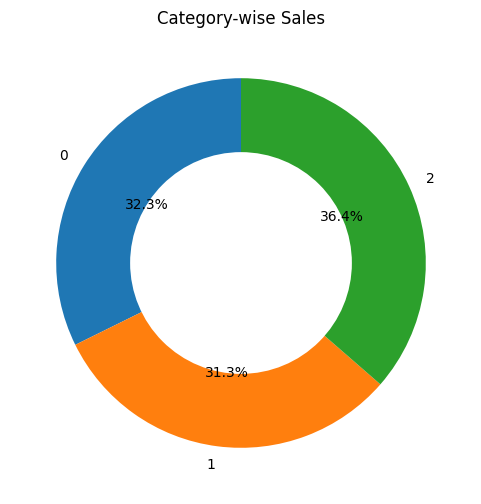

In [30]:
sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(6,6))
plt.pie(sales.values, labels=sales.index, autopct="%1.1f%%", startangle=90)
centre_circle = plt.Circle((0,0),0.60,fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Category-wise Sales")
plt.show()

OBSERVATION

* Shows the sales percentage of each category.
* One category contributes the highest sales.
* Helps identify the most popular product category

SALES DISTRIBUTION

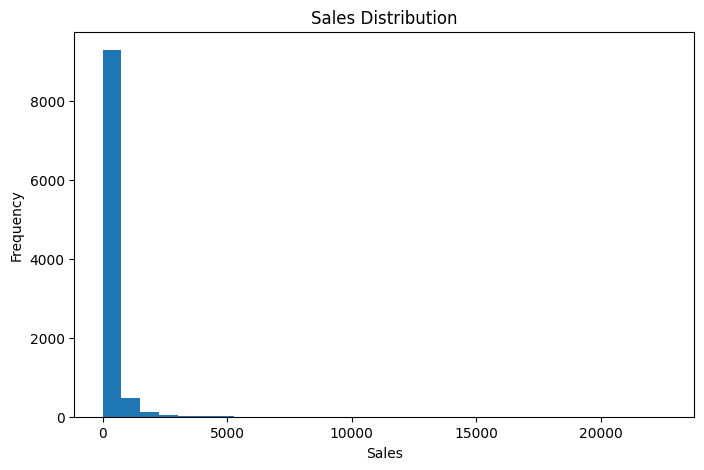

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

OBSERVATION

* Shows the distribution of sales values.
* Most sales fall within a common range.
* Only a few transactions have very high sales

MULTIPLE LINEAR REGRESSION
TRAIN TEST SPLIT

In [32]:
y=df['Sales']
x=df.drop('Sales',axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
# Create the Linear Regression Model
model = LinearRegression()


In [34]:
#train the model
model.fit(x_train,y_train)
model

LinearRegression()

In [35]:
model.coef_

array([ 1.61861365e-01, -5.82700477e-03,  1.28212476e+00,  7.15473412e-02,
       -5.26883158e-02, -3.54467975e+00,  2.44426701e-12,  6.50592148e-02,
        4.81610557e-01, -2.05140594e-04,  5.47916014e+00, -2.32168225e-01,
        1.69493202e+02,  2.04797573e+01, -3.09885805e-02,  4.19267673e+01,
        2.79198745e+02,  1.57334160e+00, -5.29310236e+01, -4.36683241e+00,
        2.82756287e-01,  3.62823471e+00])

In [36]:
model.intercept_

np.float64(106461.42482652719)

PREDICTION

In [37]:
pred=model.predict(x_test)
pred

array([245.93522117, 114.17764915, 152.06757544, ..., 242.79073836,
       314.40702253, -15.13740343])

ACTUAL VALUE VS PREDICTION VALUE

In [38]:
result=pd.DataFrame(["Actual", y_test,"predicted",pred])
result

,0
0,Actual
1,3125 563.808 1441 36.672 4510 37.30...
2,predicted
3,"[245.93522117352404, 114.17764915073349, 152.0..."


EVALUATION METRICS

In [39]:
# MSE-Mean Squared Error
mse=mean_squared_error(y_test,pred)
mse

671020.3119138557

In [40]:
# MAE-Mean Absolute Error
mae=mean_absolute_error(y_test,pred)
mae

244.94804862521931

In [41]:
#r2 Score
r2=r2_score(y_test,pred)
r2

-0.13597640586862347

FEATURE PREDICTION

In [42]:
def predict_sales():
    print("Predicting Sales based on the trained model.")

    sample_input = x_test.iloc[0:1].copy()

    try:
        quantity = float(input("Enter Quantity for prediction:"))
        sample_input['Quantity'] = quantity
    except ValueError:
        print("Invalid input for Quantity. Using default value from sample.")

    predicted_sales = model.predict(sample_input)
    print(f"Predicted Sales: {predicted_sales[0]:.2f}")

predict_sales()

Predicting Sales based on the trained model.
Enter Quantity for prediction:7
Predicted Sales: 371.72
